<a href="https://colab.research.google.com/github/nmartini15/UNCC-Machine-Learning/blob/main/Noah_Martini_801294034_Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
# import cancer dataset
df = pd.read_csv("Cancer.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [28]:
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# maps the malignant and benign to 1 and 0 respectively
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [29]:
# x is all features besides "diagnosis"
X = df.drop(columns=["diagnosis"])
# y is output, so diagnosis column
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (569, 30)
y shape: (569,)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [30]:
# splitting into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=15,
    # stratify to get ratio of positive/negative roughly equal in test/training set
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [31]:
# scales features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Create SVM classifier using a linear kernel
svm_linear = SVC(kernel="linear")

# Train the model
svm_linear.fit(X_train_scaled, y_train)

# Predict diagnosis for test data
y_pred_linear = svm_linear.predict(X_test_scaled)

# Evaluate model
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear)
linear_recall = recall_score(y_test, y_pred_linear)

print("Linear SVM")
print("Accuracy:", linear_accuracy)
print("Precision:", linear_precision)
print("Recall:", linear_recall)

Linear SVM
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9523809523809523


In [33]:
# Polynomial SVM
svm_poly = SVC(kernel="poly")

# trains poly model
svm_poly.fit(X_train_scaled, y_train)

# predicts diagnosis for test set
y_pred_poly = svm_poly.predict(X_test_scaled)

poly_accuracy = accuracy_score(y_test, y_pred_poly)
poly_precision = precision_score(y_test, y_pred_poly)
poly_recall = recall_score(y_test, y_pred_poly)

print("Polynomial SVM")
print("Accuracy:", poly_accuracy)
print("Precision:", poly_precision)
print("Recall:", poly_recall)

Polynomial SVM
Accuracy: 0.9122807017543859
Precision: 1.0
Recall: 0.7619047619047619


In [34]:
# RBF SVM
svm_rbf = SVC(kernel="rbf")

# trains rbf model
svm_rbf.fit(X_train_scaled, y_train)

# predicts diagnosis
y_pred_rbf = svm_rbf.predict(X_test_scaled)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)

print("RBF SVM")
print("Accuracy:", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall:", rbf_recall)

RBF SVM
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9523809523809523


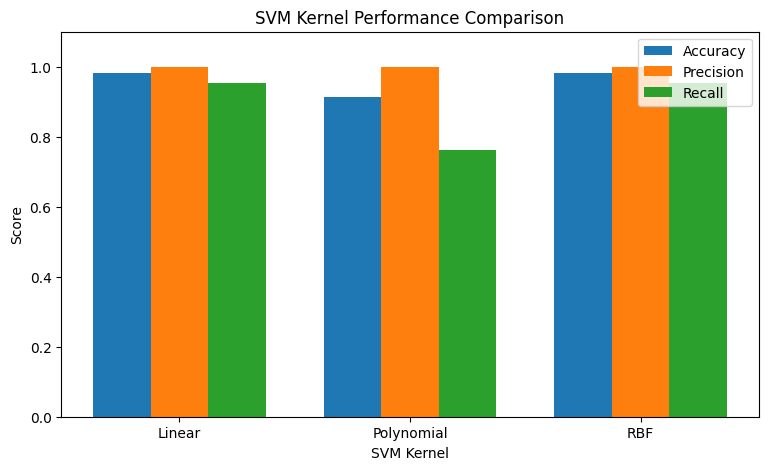

In [35]:
# plots scores of the different models

kernels = ["Linear", "Polynomial", "RBF"]

accuracies = [
    linear_accuracy,
    poly_accuracy,
    rbf_accuracy
]

precisions = [
    linear_precision,
    poly_precision,
    rbf_precision
]

recalls = [
    linear_recall,
    poly_recall,
    rbf_recall
]

x = np.arange(len(kernels))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, accuracies, width, label="Accuracy")
plt.bar(x, precisions, width, label="Precision")
plt.bar(x + width, recalls, width, label="Recall")

plt.xticks(x, kernels)
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.xlabel("SVM Kernel")
plt.title("SVM Kernel Performance Comparison")
plt.legend()

plt.show()

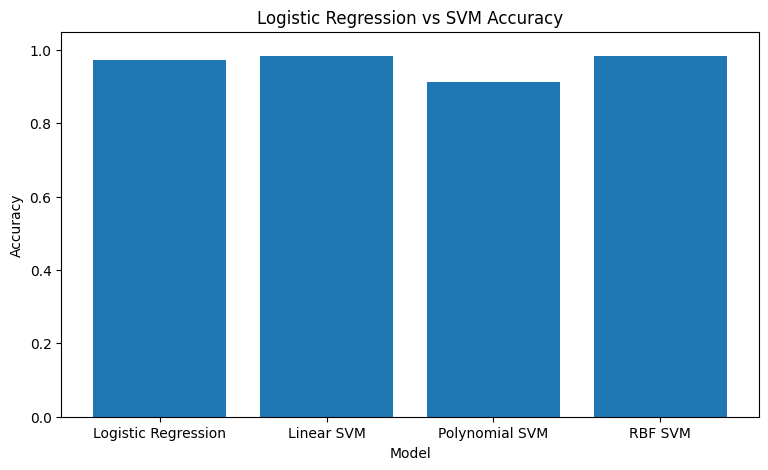

In [36]:
models = ["Logistic Regression", "Linear SVM", "Polynomial SVM", "RBF SVM"]

accuracies_compare = [
    0.9737,
    linear_accuracy,
    poly_accuracy,
    rbf_accuracy
]

plt.figure(figsize=(9, 5))

plt.bar(models, accuracies_compare)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Logistic Regression vs SVM Accuracy")

plt.show()

In [37]:
# Problem 2: SVR regression model that predicts housing price

# import housing dataset
housing = pd.read_csv("Housing.csv")

housing.head()
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [38]:
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea"
]

# X contains the 11 input features specified in the assignment
X = housing[features].copy()
# y is output/prediction: price
y = housing["price"].copy()

In [39]:
yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

# maps all of the yes/no features into 1 and 0
for column in yes_no_columns:
    X[column] = X[column].map({"yes": 1, "no": 0})

X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,1,0,0,0,1,2,1
1,8960,4,4,4,1,0,0,0,1,3,0
2,9960,3,2,2,1,0,1,0,0,2,1
3,7500,4,2,2,1,0,1,0,1,3,1
4,7420,4,1,2,1,1,1,0,1,2,0


In [40]:
# splits data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=15
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 436
Testing samples: 109


In [41]:
# scales features
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

In [42]:
# linear SVR
svr_linear = SVR(kernel="linear")

# Trains model
svr_linear.fit(X_train_scaled, y_train_scaled)

# predicts price
y_pred_linear_scaled = svr_linear.predict(X_test_scaled)

# Convert predictions back to actual house prices
y_pred_linear = y_scaler.inverse_transform(
    y_pred_linear_scaled.reshape(-1, 1)
).ravel()

In [43]:
# various error metrics for linear SVR
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear SVR")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R2:", linear_r2)

Linear SVR
MSE: 1434953308369.6248
RMSE: 1197895.3662025847
MAE: 860412.6506450829
R2: 0.6213916579054488


In [44]:
# SVR poly model
svr_poly = SVR(kernel="poly")

# training model
svr_poly.fit(X_train_scaled, y_train_scaled)

# predicts price
y_pred_poly_scaled = svr_poly.predict(X_test_scaled)

# converts prediction to actual price
y_pred_poly = y_scaler.inverse_transform(
    y_pred_poly_scaled.reshape(-1, 1)
).ravel()

# various error metrics for SVR poly
poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(poly_mse)
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial SVR")
print("MSE:", poly_mse)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)
print("R2:", poly_r2)

Polynomial SVR
MSE: 2213294141785.7427
RMSE: 1487714.401955477
MAE: 989374.952889839
R2: 0.4160286465758424


In [45]:
# SVR RBF model
svr_rbf = SVR(kernel="rbf")

# training RBF
svr_rbf.fit(X_train_scaled, y_train_scaled)

# predicts price
y_pred_rbf_scaled = svr_rbf.predict(X_test_scaled)

y_pred_rbf = y_scaler.inverse_transform(
    y_pred_rbf_scaled.reshape(-1, 1)
).ravel()

# various error metrics for RBF model
rbf_mse = mean_squared_error(y_test, y_pred_rbf)
rbf_rmse = np.sqrt(rbf_mse)
rbf_mae = mean_absolute_error(y_test, y_pred_rbf)
rbf_r2 = r2_score(y_test, y_pred_rbf)

print("RBF SVR")
print("MSE:", rbf_mse)
print("RMSE:", rbf_rmse)
print("MAE:", rbf_mae)
print("R2:", rbf_r2)

RBF SVR
MSE: 1429017031921.4468
RMSE: 1195415.0040556823
MAE: 819475.6650268211
R2: 0.6229579275332832


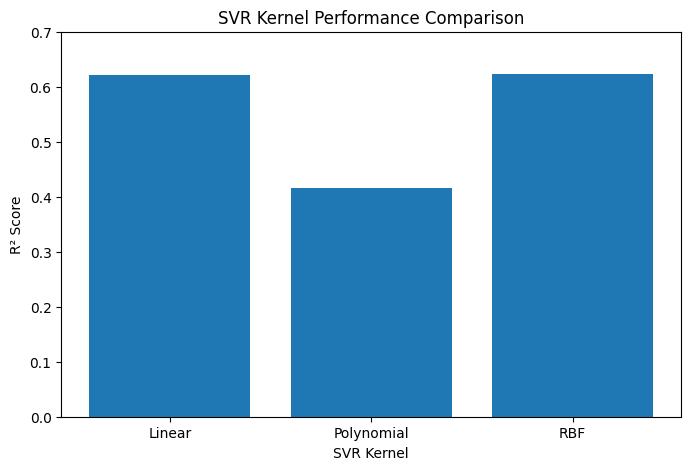

In [46]:
# plots differences in performance for the 3 models
kernels = ["Linear", "Polynomial", "RBF"]

r2_scores = [
    linear_r2,
    poly_r2,
    rbf_r2
]

plt.figure(figsize=(8, 5))

plt.bar(kernels, r2_scores)

plt.ylim(0, 0.7)
plt.xlabel("SVR Kernel")
plt.ylabel("R² Score")
plt.title("SVR Kernel Performance Comparison")

plt.show()

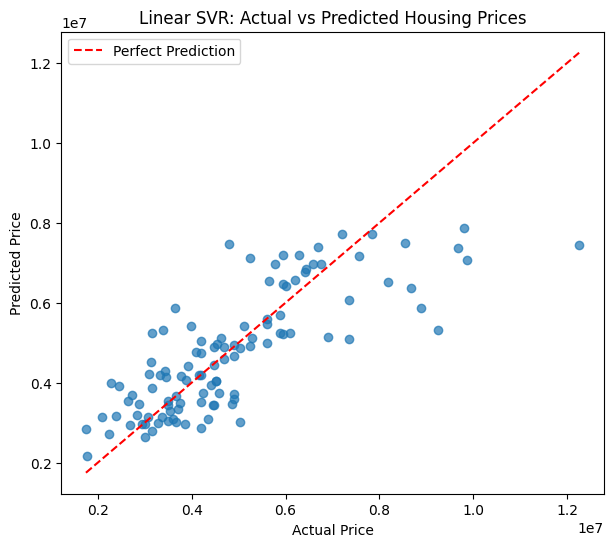

In [47]:
# plots actual housing prices against predicted prices
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.7)

# creates a line representing a perfect prediction
min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear SVR: Actual vs Predicted Housing Prices")
plt.legend()

plt.show()